# Pricing a serving stack

What effective price can an inference stack serve marketplace traffic at, and
how much of that market can it hold?

This notebook runs the whole thing. By default it **replays a stored sweep**, so
it costs nothing and takes seconds. Set `LIVE = True` in the second cell to
measure a real GPU instead — that costs 25–60 GPU-minutes.

**Setup for a fresh clone**

```bash
uv sync                 # dependencies
uv run modal token new  # your own Modal account
make deploy             # push the runner (only needed for LIVE)
```

Nothing here needs a Hugging Face token: the default checkpoint is Apache-2.0
and ungated. Nothing is account-specific — the volumes are created on first use
in whichever workspace you are logged into.

## 1. Configure

Every assumption is a field on the object. Nothing is hidden in a global.

In [1]:
import json, pathlib
from simulator import Simulator, InferenceStack, SLO

LIVE = False          # True -> measure a real GPU (25-60 min, real money)

# Resolve against the repo, not the working directory, so this runs the same
# from docs/, from the root, or from an editor that picks its own cwd.
REPO = next(p for p in pathlib.Path.cwd().resolve().parents
            if (p / "pyproject.toml").exists()) \
    if not (pathlib.Path.cwd() / "pyproject.toml").exists() else pathlib.Path.cwd()
EXAMPLE = REPO / "docs" / "examples" / "baseline-1xh100"

ROOT = REPO / "runs" / "notebook"
ROOT.mkdir(parents=True, exist_ok=True)   # root_dir must exist; artifacts land here

sim = Simulator(
    root_dir=ROOT,
    stack=InferenceStack.stock(),         # or .from_dir("overlays") for a diff
    model="Qwen/Qwen3.8-27B-FP8",
    gpu="H100", n_gpu=1,
    levels=(4, 8, 12, 16, 24),            # offered load to sweep
    seconds_per_level=120.0,
    # the cost basis: assumptions, not measurements
    gpu_provider=None,                    # None -> the agreed $3.00/hr default
    utilisation=0.50,
    note="example notebook",
)
sim.cost_basis, sim.digest()

('$3.00/GPU-hr (H100, agreed default basis)', '748b37ed4124')

### What is assumed vs measured

`assumptions()` is everything that is an *input*. None of it can be validated
from inside the harness and all of it scales the answer, so it travels with
every result.

In [2]:
sim.assumptions()

{'rate_per_gpu_hour': 3.0,
 'gpu_provider': None,
 'cost_basis': '$3.00/GPU-hr (H100, agreed default basis)',
 'utilisation': 0.5,
 'margin': 0.0,
 'market_as_of': '2026-08-31',
 'market_requests_per_day': 1398474.857142857,
 'in_per_request': 20582.81134427046,
 'out_per_request': 2075.819686592876}

### The SLO

Bounds name their own order statistic, because the market pins a TTFT *tail*
and only a TPOT *middle*: throughput percentiles run backwards, so `p99` of
throughput is the fastest 1%, and nobody publishes the slow tail.

In [3]:
print(sim.slo.describe())
for b in sim.slo.bounds:
    need = b.min_samples()
    n = f"~{need} completions" if need else "any sample size"
    print(f"  {b.label:<12} <= {b.limit_ms:>7g} ms   needs {n:<18} {b.note}")

p90 TTFT <= 2818 ms  and  p90 TPOT <= 25 ms  and  mean TPOT <= 20 ms
  p90 TTFT     <=    2818 ms   needs ~30 completions    median provider's published p90 latency
  p90 TPOT     <=      25 ms   needs ~30 completions    interactive-serving guidance -- our choice
  mean TPOT    <=      20 ms   needs any sample size    median provider's published p50 throughput


## 2. Measure

`eval()` submits, waits, analyses, and writes every artifact into `root_dir`.

In [4]:
if LIVE:
    result = await sim.eval()          # 25-60 GPU-minutes
else:
    stored = json.loads((EXAMPLE / "sweep.json").read_text())
    result = sim.finish(stored)        # same analysis, no GPU

print(result.summary())

N* = 12 users   batch 5.0   hit 0.748   7.34 GPU-s per market request
  effective input  $0.0294/M
  output           $5.6021/M
  whole bill       $12.23 per 1k requests   rank 9/12
  one node serves  0.42% of the market  (5,885 req/day)
  on effective input alone: rank 1/12  -- the metric OpenRouter sorts on, not what a buyer pays


## 3. The curve

A single price is the wrong deliverable: price depends on demand, and demand
depends on price. What the sweep produces is a curve — for every concurrency
that holds the SLO, the price and the market share one node can serve at it.

In [5]:
print(f"{"N":>5}{"batch":>7}{"hit":>7}{"GPU-s/req":>11}{"eff-in $/M":>12}"
      f"{"out $/M":>9}{"$/1k":>8}{"share":>8}  SLO")
for p in result.curve:
    print(f"{p.n_users:>5}{p.batch:>7.1f}{p.hit_rate:>7.3f}{p.gpu_s_per_request:>11.2f}"
          f"{p.effective_in_per_m:>12.4f}{p.out_per_m:>9.3f}{p.bill_per_1k:>8.2f}"
          f"{p.share_per_node:>8.2%}"
          + ("  ok" if p.meets_slo else f"  MISS <- {p.binding}"))

    N  batch    hit  GPU-s/req  eff-in $/M  out $/M    $/1k   share  SLO
    4    2.4  0.678      12.20      0.0424    9.372   20.33   0.25%  ok
    8    3.6  0.789       9.03      0.0255    7.000   15.06   0.34%  ok
   12    5.0  0.748       7.34      0.0294    5.602   12.23   0.42%  ok
   16    5.8  0.682       7.15      0.0354    5.386   11.91   0.43%  MISS <- mean TPOT
   24    8.4  0.573       5.93      0.0463    4.302    9.88   0.52%  MISS <- mean TPOT


### Which bound actually binds

The interesting part is *which* constraint gives way first — that is the
diagnosis. On 1×H100 the p90 TTFT bound is nowhere near binding and mean TPOT
sets N\*, which is why prefill work would be the wrong thing to optimise.

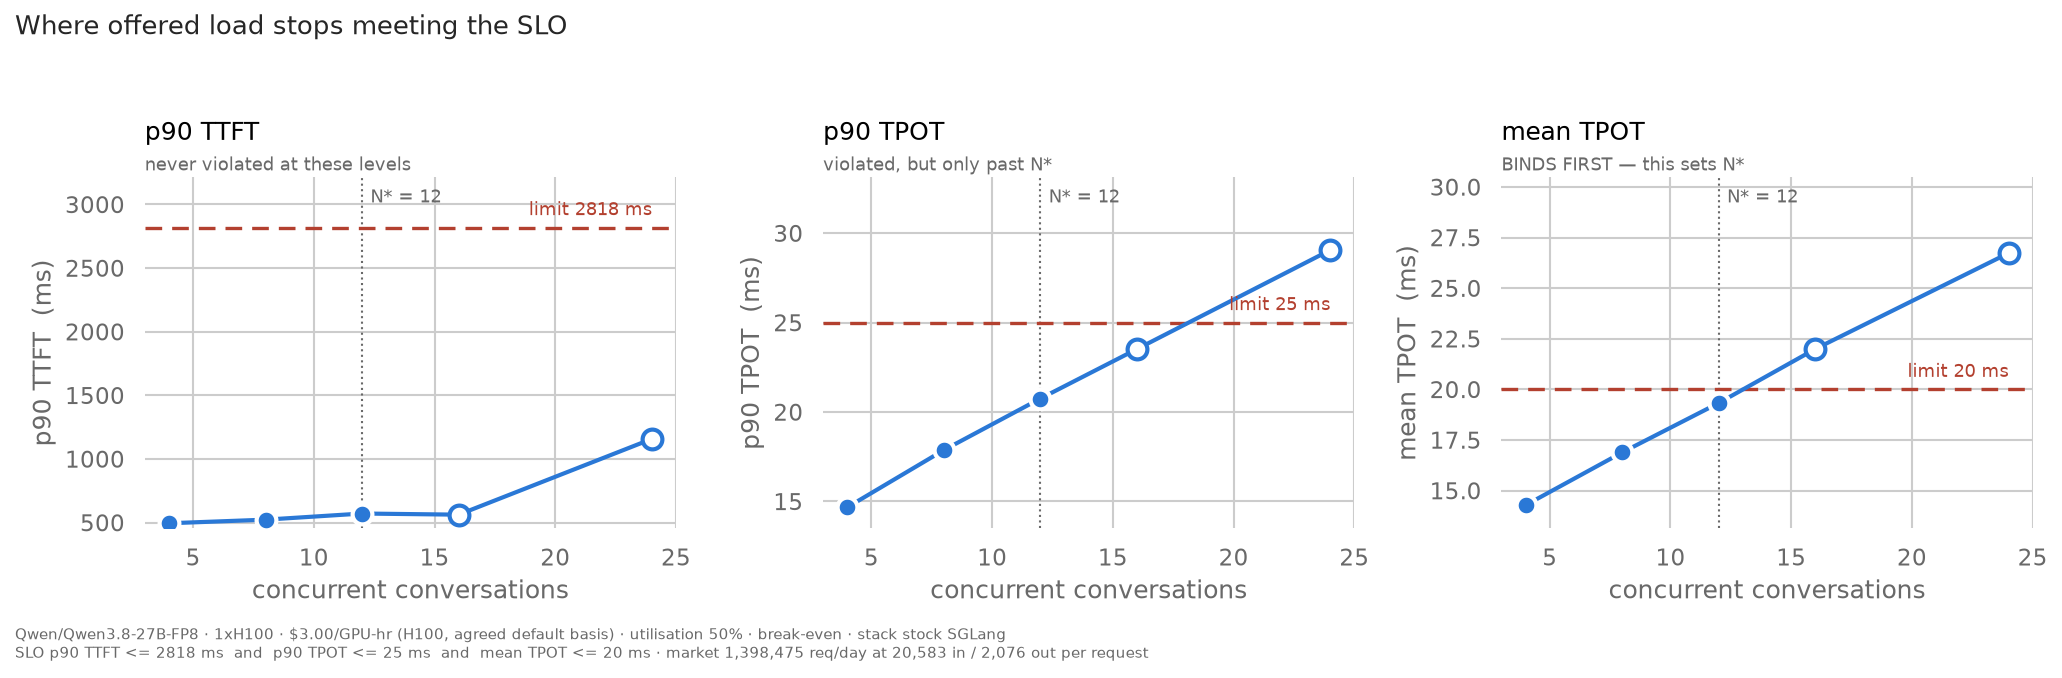

In [6]:
from IPython.display import Image, display
display(Image(filename=result.artifacts["slo_frontier"]))

## 4. Price against the market

Two ranks, always. OpenRouter sorts on **effective input price**; a buyer pays
the **whole bill**. On this baseline those give rank 1 and rank 9, because
input is only ~5% of the bill.

In [7]:
r = result.rank()
print(f"{"#":>3}  {"provider":<14}{"eff-in $/M":>12}{"out $/M":>9}{"$/1k req":>10}")
for row in r["board"]:
    print(f"{row["rank_bill"]:>3}  {row["provider"]:<14}{row["eff_in"]:>12.4f}"
          f"{row["out"]:>9.3f}{row["bill_1k"]:>10.2f}" + ("   <-- us" if row["us"] else ""))
print(f"\nrank on the bill: {r["rank_bill"]}/{r["of"]}   "
      f"rank on effective input: {r["rank_eff_in"]}/{r["of"]}")

  #  provider        eff-in $/M  out $/M  $/1k req
  1  Chutes              0.1439    2.750      8.67
  2  Novita              0.1272    3.000      8.85
  3  Alibaba             0.2160    2.550      9.74
  4  Reka                0.2257    2.550      9.94
  5  Parasail            0.1773    3.200     10.29
  6  CoreWeave           0.1988    3.000     10.32
  7  AkashML             0.2725    2.550     10.90
  8  Phala               0.2526    3.000     11.43
  9  us                  0.0294    5.602     12.23   <-- us
 10  Venice              0.4499    3.200     15.90
 11  Cloudflare          0.4499    3.200     15.90
 12  Io Net              0.4645    3.400     16.62

rank on the bill: 9/12   rank on effective input: 1/12


### Price and share are one object

Below saturation, utilisation is set by demand rather than chosen, so price
runs as `1/share` — a curve the serving stack does not enter at all. **The
stack sets only where that curve stops falling.**

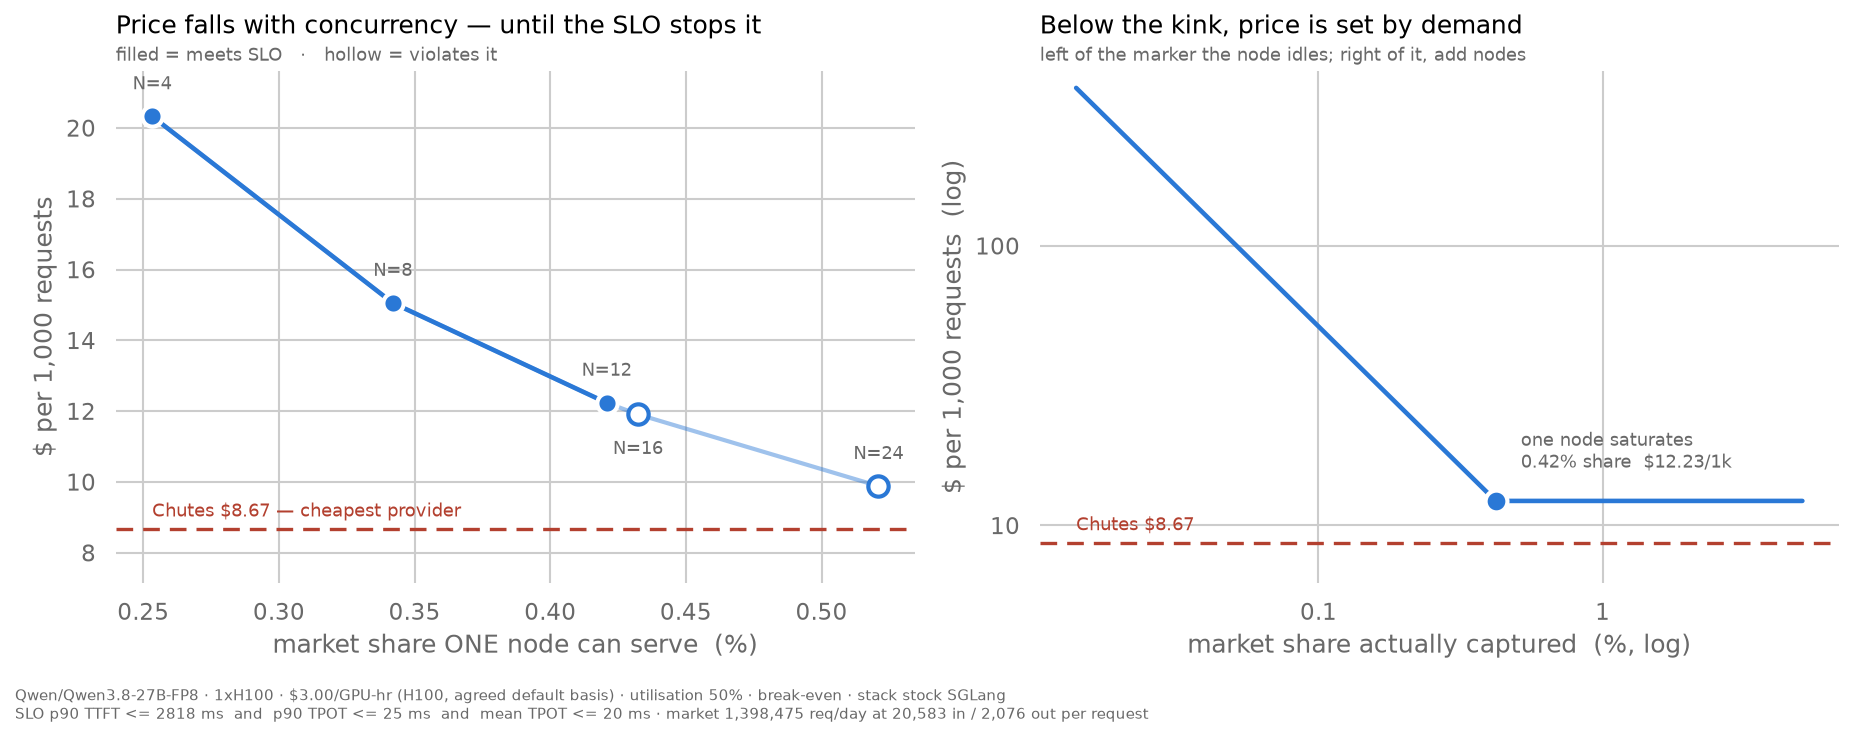

In [8]:
display(Image(filename=result.artifacts["price_vs_share"]))

In [9]:
from simulator.price.market import Economics

b = result.best
e = Economics(gpu_s_per_request=b.gpu_s_per_request, n_gpu=sim.n_gpu,
              rate_per_gpu_hour=sim.rate_per_gpu_hour, utilisation=sim.util)
m = result.market
print(f"one node: {e.capacity_per_node_per_day():,.0f} requests/day = "
      f"{e.share_per_node(m):.2%} of the market\n")
for target in (0.01, 0.05, 0.10):
    n = e.nodes_for_share(target, m)
    print(f"  {target:>5.0%} share -> {n:>5.1f} nodes "
          f"(${n * sim.n_gpu * 24 * sim.rate_per_gpu_hour:,.0f}/day)")

one node: 5,885 requests/day = 0.42% of the market

     1% share ->   2.4 nodes ($171/day)
     5% share ->  11.9 nodes ($856/day)
    10% share ->  23.8 nodes ($1,711/day)


## 5. Re-score without touching a GPU

Every level stores its full percentile set and raw counters, so changing the
SLO, the provider or the utilisation assumption is free. A sweep is 25 GPU-
minutes; re-reading it is not.

In [10]:
variants = {
    "market (default)":      dict(),
    "p99 TTFT <= 1s":        dict(slo=SLO.parse("ttft:p99:1000,tpot:p90:25,tpot:mean:20")),
    "nebius committed rate": dict(gpu_provider="nebius-committed"),
    "utilisation 25%":       dict(utilisation=0.25),
}
for name, kw in variants.items():
    s = Simulator(root_dir=ROOT, n_gpu=1, levels=sim.levels, **kw)
    r = s.analyse(result.record)
    print(f"{name:<24} N*={r.n_star or "-":<4} "
          f"eff-in ${r.effective_in_per_m or 0:.4f}/M   ${r.bill_per_1k or 0:>6.2f}/1k")

market (default)         N*=12   eff-in $0.0294/M   $ 12.23/1k
p99 TTFT <= 1s           N*=8    eff-in $0.0255/M   $ 15.06/1k
nebius committed rate    N*=12   eff-in $0.0245/M   $ 10.20/1k
utilisation 25%          N*=12   eff-in $0.0589/M   $ 24.47/1k


## 6. Evaluating a diff

The point of all this. Build an `InferenceStack` from files that mirror the
sglang package, and every evaluation gets its own sweep — a diff moves N\*, and
pricing it at the baseline's N\* would understate every latency win.

```python
stack = InferenceStack.from_dir("overlays")
sim = Simulator(root_dir="runs/my-diff", stack=stack)
result = await sim.eval()
```

`stack.digest` is a content hash, so a search loop can skip a diff it has
already evaluated instead of paying 25 GPU-minutes twice.

In [11]:
stack = InferenceStack.from_dir(REPO / "overlays")
print(stack.describe())
print("digest:", stack.digest, " (stable across processes; the cache key)")

2 modified file(s) [4adfc764fed0]: srt/managers/schedule_policy.py, srt/mem_cache/radix_cache.py
digest: 4adfc764fed0  (stable across processes; the cache key)
